In [ ]:
import zipfile
import os

ZIP_PATH = "/content/Dataset.zip"
EXTRACT_PATH = "/content/Dataset"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for item in os.listdir("/content/Dataset")[:10]:
    print(item)

Dataset


In [ ]:
import os
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical

import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [ ]:
DATA_ROOT = "/content/Dataset"

WINDOW_SIZE = 64
WINDOW_STRIDE = 16

TEST_SIZE = 0.2
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [ ]:
persons = sorted(os.listdir(DATA_ROOT))

print("Number of person folders:", len(persons))
print("\nFirst few folders:")

for p in persons[:5]:
    print(p)

Number of person folders: 1

First few folders:
Dataset


In [ ]:
DATA_ROOT = "/content/Dataset/Dataset"

print(os.listdir(DATA_ROOT)[:10])

['Person_23', 'Person_5', 'Person_10', 'Person_20', 'Person_18', 'Person_6', 'Person_28', 'Person_7', 'Person_9', 'Person_15']


In [ ]:
persons = sorted(os.listdir(DATA_ROOT))

print("Number of person folders:", len(persons))
print(persons[:5])

Number of person folders: 30
['Person_1', 'Person_10', 'Person_11', 'Person_12', 'Person_13']


In [ ]:
import glob

def list_activity_files(data_root):

    rows = []

    for person_dir in sorted(
        glob.glob(os.path.join(data_root, "Person_*"))
    ):

        person_name = os.path.basename(person_dir)

        for csvf in glob.glob(
            os.path.join(person_dir, "*.csv")
        ):

            label = os.path.splitext(
                os.path.basename(csvf)
            )[0].lower()

            rows.append(
                (csvf, label, person_name)
            )

    return rows


files = list_activity_files(DATA_ROOT)

print("Total CSV files:", len(files))
print("\nFirst 5 files:\n")

for row in files[:5]:
    print(row)

Total CSV files: 210

First 5 files:

('/content/Dataset/Dataset/Person_1/squat.csv', 'squat', 'Person_1')
('/content/Dataset/Dataset/Person_1/sitting.csv', 'sitting', 'Person_1')
('/content/Dataset/Dataset/Person_1/standing.csv', 'standing', 'Person_1')
('/content/Dataset/Dataset/Person_1/jumping.csv', 'jumping', 'Person_1')
('/content/Dataset/Dataset/Person_1/bending.csv', 'bending', 'Person_1')


In [ ]:
sample_file = files[0][0]

df = pd.read_csv(sample_file)

print(df.shape)
df.head()

(606, 77)


,timestamp,body_id,SpineBase_x,SpineBase_y,SpineBase_z,SpineMid_x,SpineMid_y,SpineMid_z,Neck_x,Neck_y,...,HandTipLeft_z,ThumbLeft_x,ThumbLeft_y,ThumbLeft_z,HandTipRight_x,HandTipRight_y,HandTipRight_z,ThumbRight_x,ThumbRight_y,ThumbRight_z
0,0.004005,5,0.027745,-0.146318,2.772642,0.021395,0.173385,2.727971,0.015109,0.484435,...,2.614319,-0.155851,-0.173612,2.655126,0.252888,-0.260597,2.676996,0.220128,-0.200692,2.689572
1,0.039594,5,0.027655,-0.146428,2.772310,0.021348,0.173301,2.727742,0.015094,0.484389,...,2.620311,-0.157414,-0.177776,2.655385,0.249560,-0.262301,2.680630,0.190543,-0.151240,2.695750
2,0.071534,5,0.027696,-0.146429,2.772046,0.021334,0.173275,2.727556,0.015044,0.484357,...,2.610889,-0.156394,-0.201327,2.632294,0.255291,-0.260127,2.681911,0.192890,-0.153558,2.697423
3,0.104765,5,0.027754,-0.146261,2.771805,0.021257,0.173484,2.727225,0.014779,0.484641,...,2.613719,-0.154650,-0.171557,2.655937,0.250723,-0.260869,2.685843,0.212383,-0.201625,2.682111
4,0.140564,5,0.027770,-0.146283,2.771719,0.021266,0.173484,2.727050,0.014776,0.484686,...,2.610320,-0.155122,-0.153991,2.660000,0.256823,-0.259234,2.680462,0.226302,-0.238412,2.678333


In [ ]:
def read_csv_numeric(filepath):

    df = pd.read_csv(filepath)

    df.columns = df.columns.str.strip()

    numeric = df.iloc[:, 2:]  # remove timestamp + body_id

    numeric = numeric.apply(
        pd.to_numeric,
        errors="coerce"
    )

    numeric = numeric.fillna(0)

    return numeric.values.astype(np.float32)


def sliding_windows(
    seq_array,
    window_size=64,
    stride=16
):

    T, F = seq_array.shape

    windows = []

    for start in range(
        0,
        T - window_size + 1,
        stride
    ):

        windows.append(
            seq_array[
                start:start + window_size
            ]
        )

    return np.array(windows)

In [ ]:
X_windows = []
y_windows = []
persons = []

for fp, label, person in files:

    arr = read_csv_numeric(fp)

    windows = sliding_windows(
        arr,
        window_size=64,
        stride=16
    )

    X_windows.append(windows)

    y_windows.extend(
        [label] * len(windows)
    )

    persons.extend(
        [person] * len(windows)
    )

X = np.vstack(X_windows)

print("X shape:", X.shape)
print("Labels:", len(y_windows))

X shape: (7395, 64, 75)
Labels: 7395


In [ ]:
print(X.shape)

(7395, 64, 75)


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()

y = le.fit_transform(y_windows)

print("Classes:")
print(le.classes_)

nsamples, nt, nf = X.shape

X_flat = X.reshape(-1, nf)

scaler = StandardScaler()

X_flat = scaler.fit_transform(X_flat)

X = X_flat.reshape(nsamples, nt, nf)

print("Normalized X shape:", X.shape)

Classes:
['bending' 'jumping' 'running' 'sitting' 'squat' 'standing' 'walking']
Normalized X shape: (7395, 64, 75)


In [ ]:
persons = np.array(persons)

unique_persons = np.unique(persons)

train_persons, test_persons = train_test_split(
    unique_persons,
    test_size=0.2,
    random_state=42
)

train_mask = np.isin(
    persons,
    train_persons
)

test_mask = ~train_mask

X_train = X[train_mask]
X_test  = X[test_mask]

y_train = y[train_mask]
y_test  = y[test_mask]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (5940, 64, 75)
Test : (1455, 64, 75)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)

y_test_cat = to_categorical(y_test)

print(y_train_cat.shape)
print(y_test_cat.shape)

(5940, 7)
(1455, 7)


In [ ]:
print(X_train.shape)
print(X_test.shape)

(5940, 64, 75)
(1455, 64, 75)


In [ ]:
reward_weights = tf.constant([
    1.00,  # bending
    1.26,  # jumping
    1.05,  # running
    1.00,  # sitting
    1.02,  # squat
    1.00,  # standing
    1.00   # walking
], dtype=tf.float32)

In [ ]:
def reward_shaped_loss(alpha=0.02):

    def loss_fn(y_true, y_pred):

        ce_loss = tf.keras.losses.categorical_crossentropy(
            y_true,
            y_pred
        )

        true_class = tf.argmax(
            y_true,
            axis=1
        )

        true_probs = tf.reduce_sum(
            y_true * y_pred,
            axis=1
        )

        rewards = tf.gather(
            reward_weights,
            true_class
        )

        penalty = (1.0 - true_probs) * rewards

        total_loss = ce_loss + alpha * penalty

        return total_loss

    return loss_fn

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(64,75)
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.2))

model.add(Dense(7, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,455 (158.03 KB)

 Trainable params: 40,455 (158.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=reward_shaped_loss(alpha=0.02),
    metrics=['accuracy']
)

In [ ]:
callbacks = [

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

]

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(test_acc)

0.15189003944396973


In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6358 - loss: 1.0058 - val_accuracy: 0.5735 - val_loss: 1.0275 - learning_rate: 0.0010
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8604 - loss: 0.4040 - val_accuracy: 0.6364 - val_loss: 1.3652 - learning_rate: 0.0010
Epoch 3/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9218 - loss: 0.2451 - val_accuracy: 0.5600 - val_loss: 1.8473 - learning_rate: 0.0010
Epoch 4/20
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9188 - loss: 0.2524
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9184 - loss: 0.2661 - val_accuracy: 0.6431 - val_loss: 1.6756 - learning_rate: 0.0010
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9556 - loss: 0.1493 - val_accuracy: 0.6543 - val_loss: 1.6664 - learning_rate: 5.0000e-04
Epoch 6/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9673 - loss: 0.1

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.7099656462669373


TEST

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

baseline_model = Sequential()

baseline_model.add(
    LSTM(
        128,
        input_shape=(64,75)
    )
)

baseline_model.add(Dropout(0.3))

baseline_model.add(
    Dense(
        64,
        activation='relu'
    )
)

baseline_model.add(Dropout(0.2))

baseline_model.add(
    Dense(
        7,
        activation='softmax'
    )
)

baseline_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │       104,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,159 (442.03 KB)

 Trainable params: 113,159 (442.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = baseline_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.7148 - loss: 0.7919 - val_accuracy: 0.6072 - val_loss: 1.0829 - learning_rate: 0.0010
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8703 - loss: 0.3717 - val_accuracy: 0.6285 - val_loss: 1.3962 - learning_rate: 0.0010
Epoch 3/20
154/158 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8979 - loss: 0.2855
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9156 - loss: 0.2518 - val_accuracy: 0.6644 - val_loss: 1.6708 - learning_rate: 0.0010
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9556 - loss: 0.1621 - val_accuracy: 0.6700 - val_loss: 1.7750 - learning_rate: 5.0000e-04
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9778 - loss: 0.0975 - val_accuracy: 0.6397 - val_loss: 2.2617 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoc

In [ ]:
test_loss, test_acc = baseline_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.853608250617981


In [ ]:
from collections import Counter

print("Train")
print(Counter(y_train))

print("\nTest")
print(Counter(y_test))

Train
Counter({np.int64(5): 886, np.int64(0): 875, np.int64(1): 863, np.int64(3): 833, np.int64(4): 832, np.int64(6): 831, np.int64(2): 820})

Test
Counter({np.int64(3): 211, np.int64(5): 210, np.int64(0): 210, np.int64(4): 208, np.int64(6): 207, np.int64(1): 205, np.int64(2): 204})


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_pred_probs = baseline_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred)

print(cm)

print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=le.classes_,
        digits=4
    )
)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[182   0   0   0  19   7   2]
 [  0 111   2   0   2  28  62]
 [  0  28 148   0   0   0  28]
 [  0   0   0 211   0   0   0]
 [  8   0   0   2 196   0   2]
 [  0   0   0   0   0 210   0]
 [  0   4   0   0   9  10 184]]

Classification Report:

              precision    recall  f1-score   support

     bending     0.9579    0.8667    0.9100       210
     jumping     0.7762    0.5415    0.6379       205
     running     0.9867    0.7255    0.8362       204
     sitting     0.9906    1.0000    0.9953       211
       squat     0.8673    0.9423    0.9032       208
    standing     0.8235    1.0000    0.9032       210
     walking     0.6619    0.8889    0.7588       207

    accuracy                         0.8536      1455
   macro avg     0.8663    0.8521    0.8492      1455
weighted avg     0.8666    0.8536    0.8502      1455



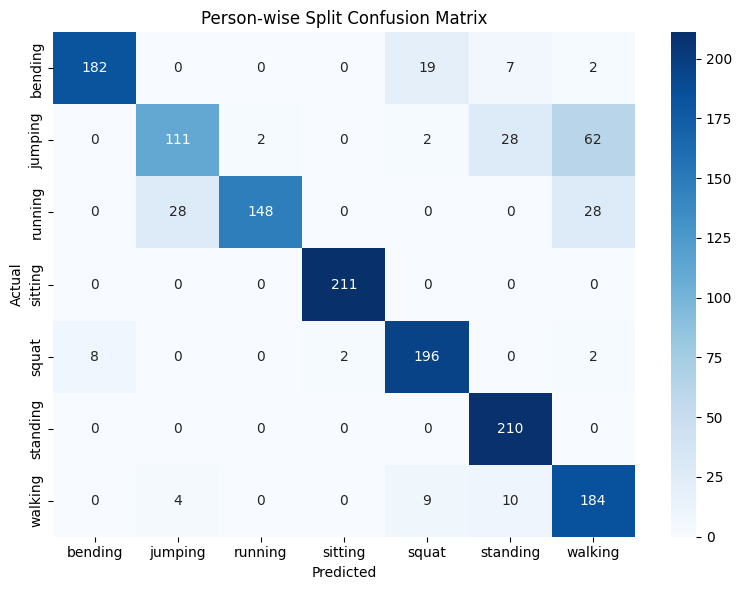

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Person-wise Split Confusion Matrix")

plt.tight_layout()
plt.show()

In [ ]:
JUMPING_IDX = list(le.classes_).index('jumping')
RUNNING_IDX = list(le.classes_).index('running')
WALKING_IDX = list(le.classes_).index('walking')

print(JUMPING_IDX, RUNNING_IDX, WALKING_IDX)

1 2 6


In [ ]:
import tensorflow as tf

JUMPING_IDX = 1
RUNNING_IDX = 2
WALKING_IDX = 6

def confusion_aware_loss(lambda_penalty=0.30):

    def loss_fn(y_true, y_pred):

        ce = tf.keras.losses.categorical_crossentropy(
            y_true,
            y_pred
        )

        true_class = tf.argmax(
            y_true,
            axis=1,
            output_type=tf.int32
        )

        running_prob = y_pred[:, RUNNING_IDX]

        walking_prob = y_pred[:, WALKING_IDX]

        jumping_mask = tf.cast(
            tf.equal(true_class, JUMPING_IDX),
            tf.float32
        )

        confusion_penalty = (
            jumping_mask *
            (running_prob + walking_prob)
        )

        return ce + lambda_penalty * confusion_penalty

    return loss_fn

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

reward_model = Sequential()

reward_model.add(
    LSTM(
        128,
        input_shape=(64,75)
    )
)

reward_model.add(
    Dropout(0.3)
)

reward_model.add(
    Dense(
        64,
        activation='relu'
    )
)

reward_model.add(
    Dropout(0.2)
)

reward_model.add(
    Dense(
        7,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
reward_model.compile(
    optimizer='adam',
    loss=confusion_aware_loss(
        lambda_penalty=0.30
    ),
    metrics=['accuracy']
)

In [ ]:
history = reward_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7089 - loss: 0.8226 - val_accuracy: 0.6139 - val_loss: 1.4075 - learning_rate: 0.0010
Epoch 2/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8707 - loss: 0.4042 - val_accuracy: 0.6734 - val_loss: 1.2216 - learning_rate: 0.0010
Epoch 3/20
156/158 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8836 - loss: 0.3855
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8895 - loss: 0.3638 - val_accuracy: 0.6061 - val_loss: 1.8079 - learning_rate: 0.0010
Epoch 4/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9461 - loss: 0.1895 - val_accuracy: 0.6869 - val_loss: 1.7830 - learning_rate: 5.0000e-04
Epoch 5/20
158/158 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9531 - loss: 0.1586 - val_accuracy: 0.6274 - val_loss: 2.1389 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch

In [ ]:
test_loss, test_acc = reward_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.7532646059989929


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = np.argmax(
    reward_model.predict(X_test),
    axis=1
)

y_true = np.argmax(
    y_test_cat,
    axis=1
)

cm = confusion_matrix(y_true, y_pred)

print(cm)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=le.classes_,
        digits=4
    )
)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[130   0   0   0  38  28  14]
 [  0  74  42   0   8  25  56]
 [  0   3 135   0  56   0  10]
 [  0   0   0 211   0   0   0]
 [  1   0   0   0 207   0   0]
 [  0   0   0   0  34 140  36]
 [  0   1   0   0   0   7 199]]
              precision    recall  f1-score   support

     bending     0.9924    0.6190    0.7625       210
     jumping     0.9487    0.3610    0.5230       205
     running     0.7627    0.6618    0.7087       204
     sitting     1.0000    1.0000    1.0000       211
       squat     0.6035    0.9952    0.7514       208
    standing     0.7000    0.6667    0.6829       210
     walking     0.6317    0.9614    0.7625       207

    accuracy                         0.7533      1455
   macro avg     0.8056    0.7521    0.7415      1455
weighted avg     0.8060    0.7533    0.7426      1455



46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[130   0   0   0  38  28  14]
 [  0  74  42   0   8  25  56]
 [  0   3 135   0  56   0  10]
 [  0   0   0 211   0   0   0]
 [  1   0   0   0 207   0   0]
 [  0   0   0   0  34 140  36]
 [  0   1   0   0   0   7 199]]
              precision    recall  f1-score   support

     bending     0.9924    0.6190    0.7625       210
     jumping     0.9487    0.3610    0.5230       205
     running     0.7627    0.6618    0.7087       204
     sitting     1.0000    1.0000    1.0000       211
       squat     0.6035    0.9952    0.7514       208
    standing     0.7000    0.6667    0.6829       210
     walking     0.6317    0.9614    0.7625       207

    accuracy                         0.7533      1455
   macro avg     0.8056    0.7521    0.7415      1455
weighted avg     0.8060    0.7533    0.7426      1455



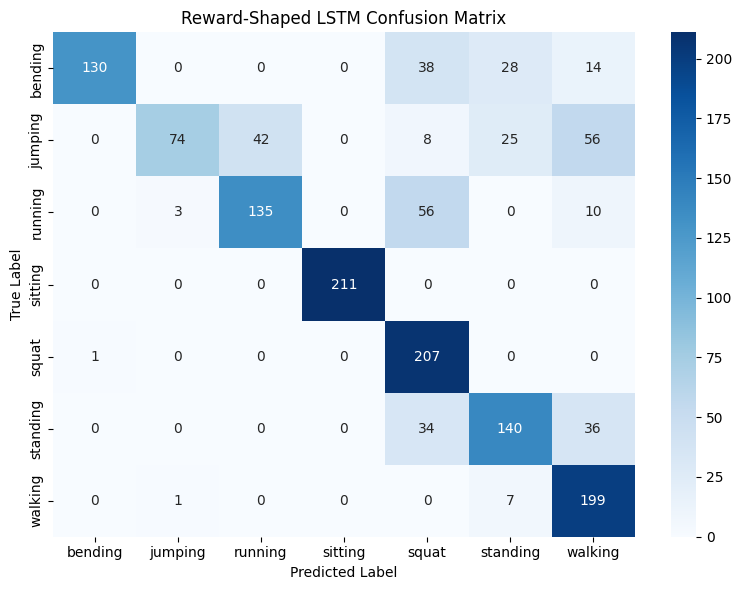

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(
    reward_model.predict(X_test),
    axis=1
)

y_true = np.argmax(
    y_test_cat,
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=le.classes_,
        digits=4
    )
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Reward-Shaped LSTM Confusion Matrix")

plt.tight_layout()
plt.show()